# Week 3 ：NLP 文本表示与词向量

- 作者：邓涵丹
- 日期：2026-07-21
- 来源：`暑期居家集训学习计划.md` → Week 3 → NLP 文本表示基础
- 适用周次：Week 3
- 分类：NLP
- 关键词：TF-IDF、Word2Vec、t-SNE、词向量可视化
- 运行环境：Python 3.10+、NumPy、Matplotlib、scikit-learn、gensim、nltk

## 学习目标

1. 使用 TF‑IDF 将文本转换为稀疏向量，并用 t‑SNE 进行文档级可视化。
2. 训练一个轻量级 Word2Vec 模型，理解词向量的语义空间。
3. 对词向量进行 t‑SNE 降维展示，并演示相似词和类比推理。

> 本 Notebook 使用离线构造的小型文本集合，避免第一次运行就依赖外部语料或预训练模型。

In [5]:
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# 首次运行需下载 nltk 数据（已下载则跳过）
nltk.download('punkt')

nltk.download('punkt_tab') 
nltk.download('wordnet')
nltk.download('stopwords')
%matplotlib inline

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
def preprocess_en(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return tokens

def preprocess_en_to_str(text):
    return " ".join(preprocess_en(text))

In [8]:
texts = [
    'image classification with convolutional networks',
    'deep learning models classify images accurately',
    'vision features can detect objects and edges',
    'text classification uses word representations',
    'language models learn useful text features',
    'tf idf represents documents with sparse vectors',
    'video understanding models temporal features',
    'temporal modeling is useful for video analysis',
    'anomaly detection compares normal and unusual patterns',
]

# 预处理后的文本（用于 TF-IDF）
clean_strs = [preprocess_en_to_str(t) for t in texts]
# 分词后的列表（用于 Word2Vec）
tokenized = [preprocess_en(t) for t in texts]

print("原始文档数：", len(texts))
print("示例预处理结果：", clean_strs[0])

原始文档数： 9
示例预处理结果： image classification convolutional network


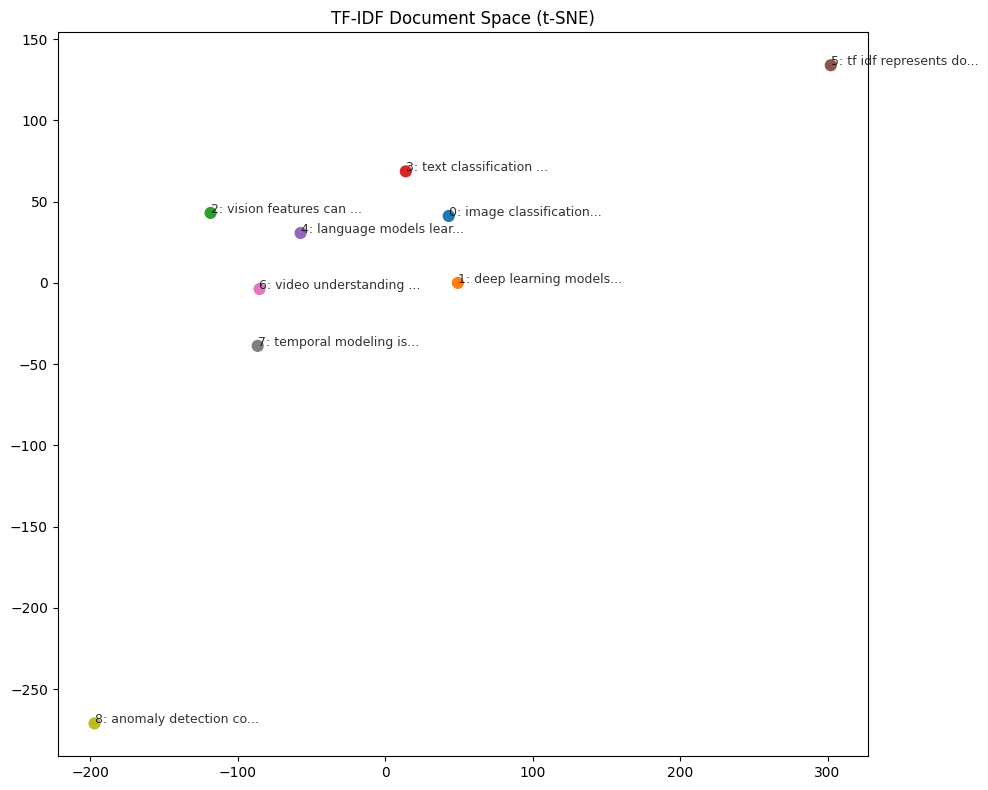

In [9]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
tfidf_vectors = vectorizer.fit_transform(clean_strs).toarray()

# t‑SNE 降维（perplexity 应小于样本数）
tsne = TSNE(n_components=2, perplexity=3, random_state=42, init='random')
doc_pos = tsne.fit_transform(tfidf_vectors)

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.arange(len(texts)))
plt.scatter(doc_pos[:, 0], doc_pos[:, 1], c=colors, s=60)
for i, txt in enumerate(texts):
    plt.annotate(f'{i}: {txt[:20]}...', doc_pos[i], fontsize=9, alpha=0.8)
plt.title('TF‑IDF Document Space (t‑SNE)')
plt.tight_layout()
plt.show()

In [10]:
w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,          # Skip‑gram
    epochs=20,
    seed=42
)
wv = w2v_model.wv
print(f"词汇表大小：{len(wv.key_to_index)}")

词汇表大小：38


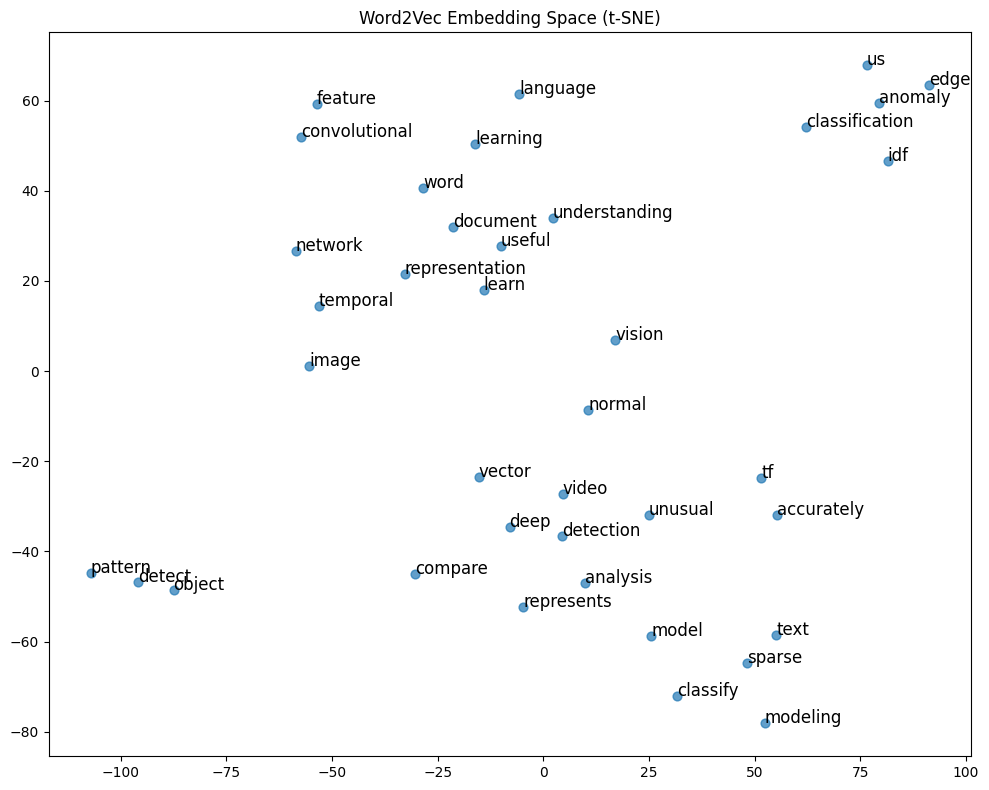

In [11]:
words = list(wv.key_to_index.keys())
word_vectors = np.array([wv[word] for word in words])

tsne_words = TSNE(n_components=2, perplexity=3, random_state=42, init='random')
word_pos = tsne_words.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(word_pos[:, 0], word_pos[:, 1], alpha=0.7, s=40)
for i, w in enumerate(words):
    plt.annotate(w, word_pos[i], fontsize=12)
plt.title('Word2Vec Embedding Space (t‑SNE)')
plt.tight_layout()
plt.show()

In [12]:
# 相似词
print("与 'image' 最相似的词：", wv.most_similar('image', topn=3))
print("与 'model' 最相似的词：", wv.most_similar('model', topn=3))

# 相似度计算
print("\n'image' 与 'vision' 的相似度：", wv.similarity('image', 'vision'))
print("'text' 与 'feature' 的相似度：", wv.similarity('text', 'feature'))

# 类比推理（示例：image 之于 vision 类比 text 之于 ?）
# 尝试找出与 text 最相似的词，类比 image:vision
try:
    analogies = wv.most_similar(positive=['vision', 'text'], negative=['image'], topn=2)
    print("\n类比推理 image → vision，text → ?：", analogies)
except KeyError as e:
    print("\n类比失败，词汇表中缺少某些词：", e)

与 'image' 最相似的词： [('temporal', 0.1907317042350769), ('language', 0.13976940512657166), ('pattern', 0.1376713067293167)]
与 'model' 最相似的词： [('detection', 0.33208581805229187), ('sparse', 0.2509211301803589), ('deep', 0.21964211761951447)]

'image' 与 'vision' 的相似度： -0.16311263
'text' 与 'feature' 的相似度： -0.05490913

类比推理 image → vision，text → ?： [('classification', 0.31005117297172546), ('normal', 0.215904101729393)]


## 7. 小结

本 Notebook 演示了：
- TF‑IDF 文档表示及 t‑SNE 可视化
- Word2Vec 训练与词向量空间可视化
- 基本的语义相似性和类比推理

**扩展方向**：
- 使用更大语料（如 20 Newsgroups）训练更有意义的词向量
- 加载预训练词向量（腾讯中文词向量或 GloVe）
- 将词向量用于下游分类任务，并与 TF‑IDF 做对比
- 尝试 CBOW 模型 (`sg=0`) 或调整超参数
。